<a href="https://www.kaggle.com/code/lalit7881/healthcare-disease-prediction-eda?scriptVersionId=312212975" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rafi003/healthcare-disease-prediction-dataset/healthcare_disease_prediction_2000.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rafi003/healthcare-disease-prediction-dataset/healthcare_disease_prediction_2000.csv")

In [3]:
df.head()

,Patient_ID,Age,Gender,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,Glucose_Level,Smoking,Alcohol_Intake,Physical_Activity,Family_History,Heart_Disease,Diabetes,Stroke
0,1,69,Male,34.1,127,71,184,154,1,1,0,0,0,1,0
1,2,32,Male,25.0,148,69,177,136,1,1,1,0,0,0,0
2,3,78,Male,25.2,98,93,252,110,0,0,0,0,0,0,0
3,4,38,Male,9.6,162,102,274,87,1,0,1,0,0,0,0
4,5,41,Female,29.0,161,69,251,127,0,1,1,0,0,0,0


In [4]:
df.tail()

,Patient_ID,Age,Gender,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,Glucose_Level,Smoking,Alcohol_Intake,Physical_Activity,Family_History,Heart_Disease,Diabetes,Stroke
1995,1996,19,Male,28.0,114,100,255,91,1,1,1,0,0,0,0
1996,1997,46,Female,35.2,92,86,295,133,0,0,1,0,0,0,0
1997,1998,69,Male,30.1,98,114,179,90,0,1,0,0,0,0,0
1998,1999,44,Male,23.2,175,94,159,198,1,1,1,0,0,0,0
1999,2000,67,Male,25.8,176,111,211,176,0,0,1,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   BMI                       2000 non-null   float64
 4   Blood_Pressure_Systolic   2000 non-null   int64  
 5   Blood_Pressure_Diastolic  2000 non-null   int64  
 6   Cholesterol               2000 non-null   int64  
 7   Glucose_Level             2000 non-null   int64  
 8   Smoking                   2000 non-null   int64  
 9   Alcohol_Intake            2000 non-null   int64  
 10  Physical_Activity         2000 non-null   int64  
 11  Family_History            2000 non-null   int64  
 12  Heart_Disease             2000 non-null   int64  
 13  Diabetes                  2000 non-null   int64  
 14  Stroke  

In [6]:
df.describe()

,Patient_ID,Age,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,Glucose_Level,Smoking,Alcohol_Intake,Physical_Activity,Family_History,Heart_Disease,Diabetes,Stroke
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,50.273000,26.977350,134.523500,88.995500,223.980500,132.979500,0.496000,0.503000,0.4950,0.501500,0.080500,0.131000,0.051000
std,577.494589,19.427202,4.945219,26.139856,17.222043,43.212993,37.039574,0.500109,0.500116,0.5001,0.500123,0.272134,0.337485,0.220053
min,1.000000,18.000000,9.600000,90.000000,60.000000,150.000000,70.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,33.750000,23.600000,112.000000,74.000000,187.000000,100.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,50.000000,26.900000,134.500000,89.000000,224.000000,133.000000,0.000000,1.000000,0.0000,1.000000,0.000000,0.000000,0.000000
75%,1500.250000,67.000000,30.500000,158.000000,104.000000,261.000000,165.000000,1.000000,1.000000,1.0000,1.000000,0.000000,0.000000,0.000000
max,2000.000000,84.000000,42.300000,179.000000,119.000000,299.000000,199.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

Patient_ID                  0
Age                         0
Gender                      0
BMI                         0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Cholesterol                 0
Glucose_Level               0
Smoking                     0
Alcohol_Intake              0
Physical_Activity           0
Family_History              0
Heart_Disease               0
Diabetes                    0
Stroke                      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Patient_ID                    int64
Age                           int64
Gender                       object
BMI                         float64
Blood_Pressure_Systolic       int64
Blood_Pressure_Diastolic      int64
Cholesterol                   int64
Glucose_Level                 int64
Smoking                       int64
Alcohol_Intake                int64
Physical_Activity             int64
Family_History                int64
Heart_Disease                 int64
Diabetes                      int64
Stroke                        int64
dtype: object

In [10]:
df.shape

(2000, 15)

In [11]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Cholesterol', 'Glucose_Level', 'Smoking',
       'Alcohol_Intake', 'Physical_Activity', 'Family_History',
       'Heart_Disease', 'Diabetes', 'Stroke'],
      dtype='object')

In [12]:
df.nunique()

Patient_ID                  2000
Age                           67
Gender                         2
BMI                          250
Blood_Pressure_Systolic       90
Blood_Pressure_Diastolic      60
Cholesterol                  150
Glucose_Level                130
Smoking                        2
Alcohol_Intake                 2
Physical_Activity              2
Family_History                 2
Heart_Disease                  2
Diabetes                       2
Stroke                         2
dtype: int64

## EDA

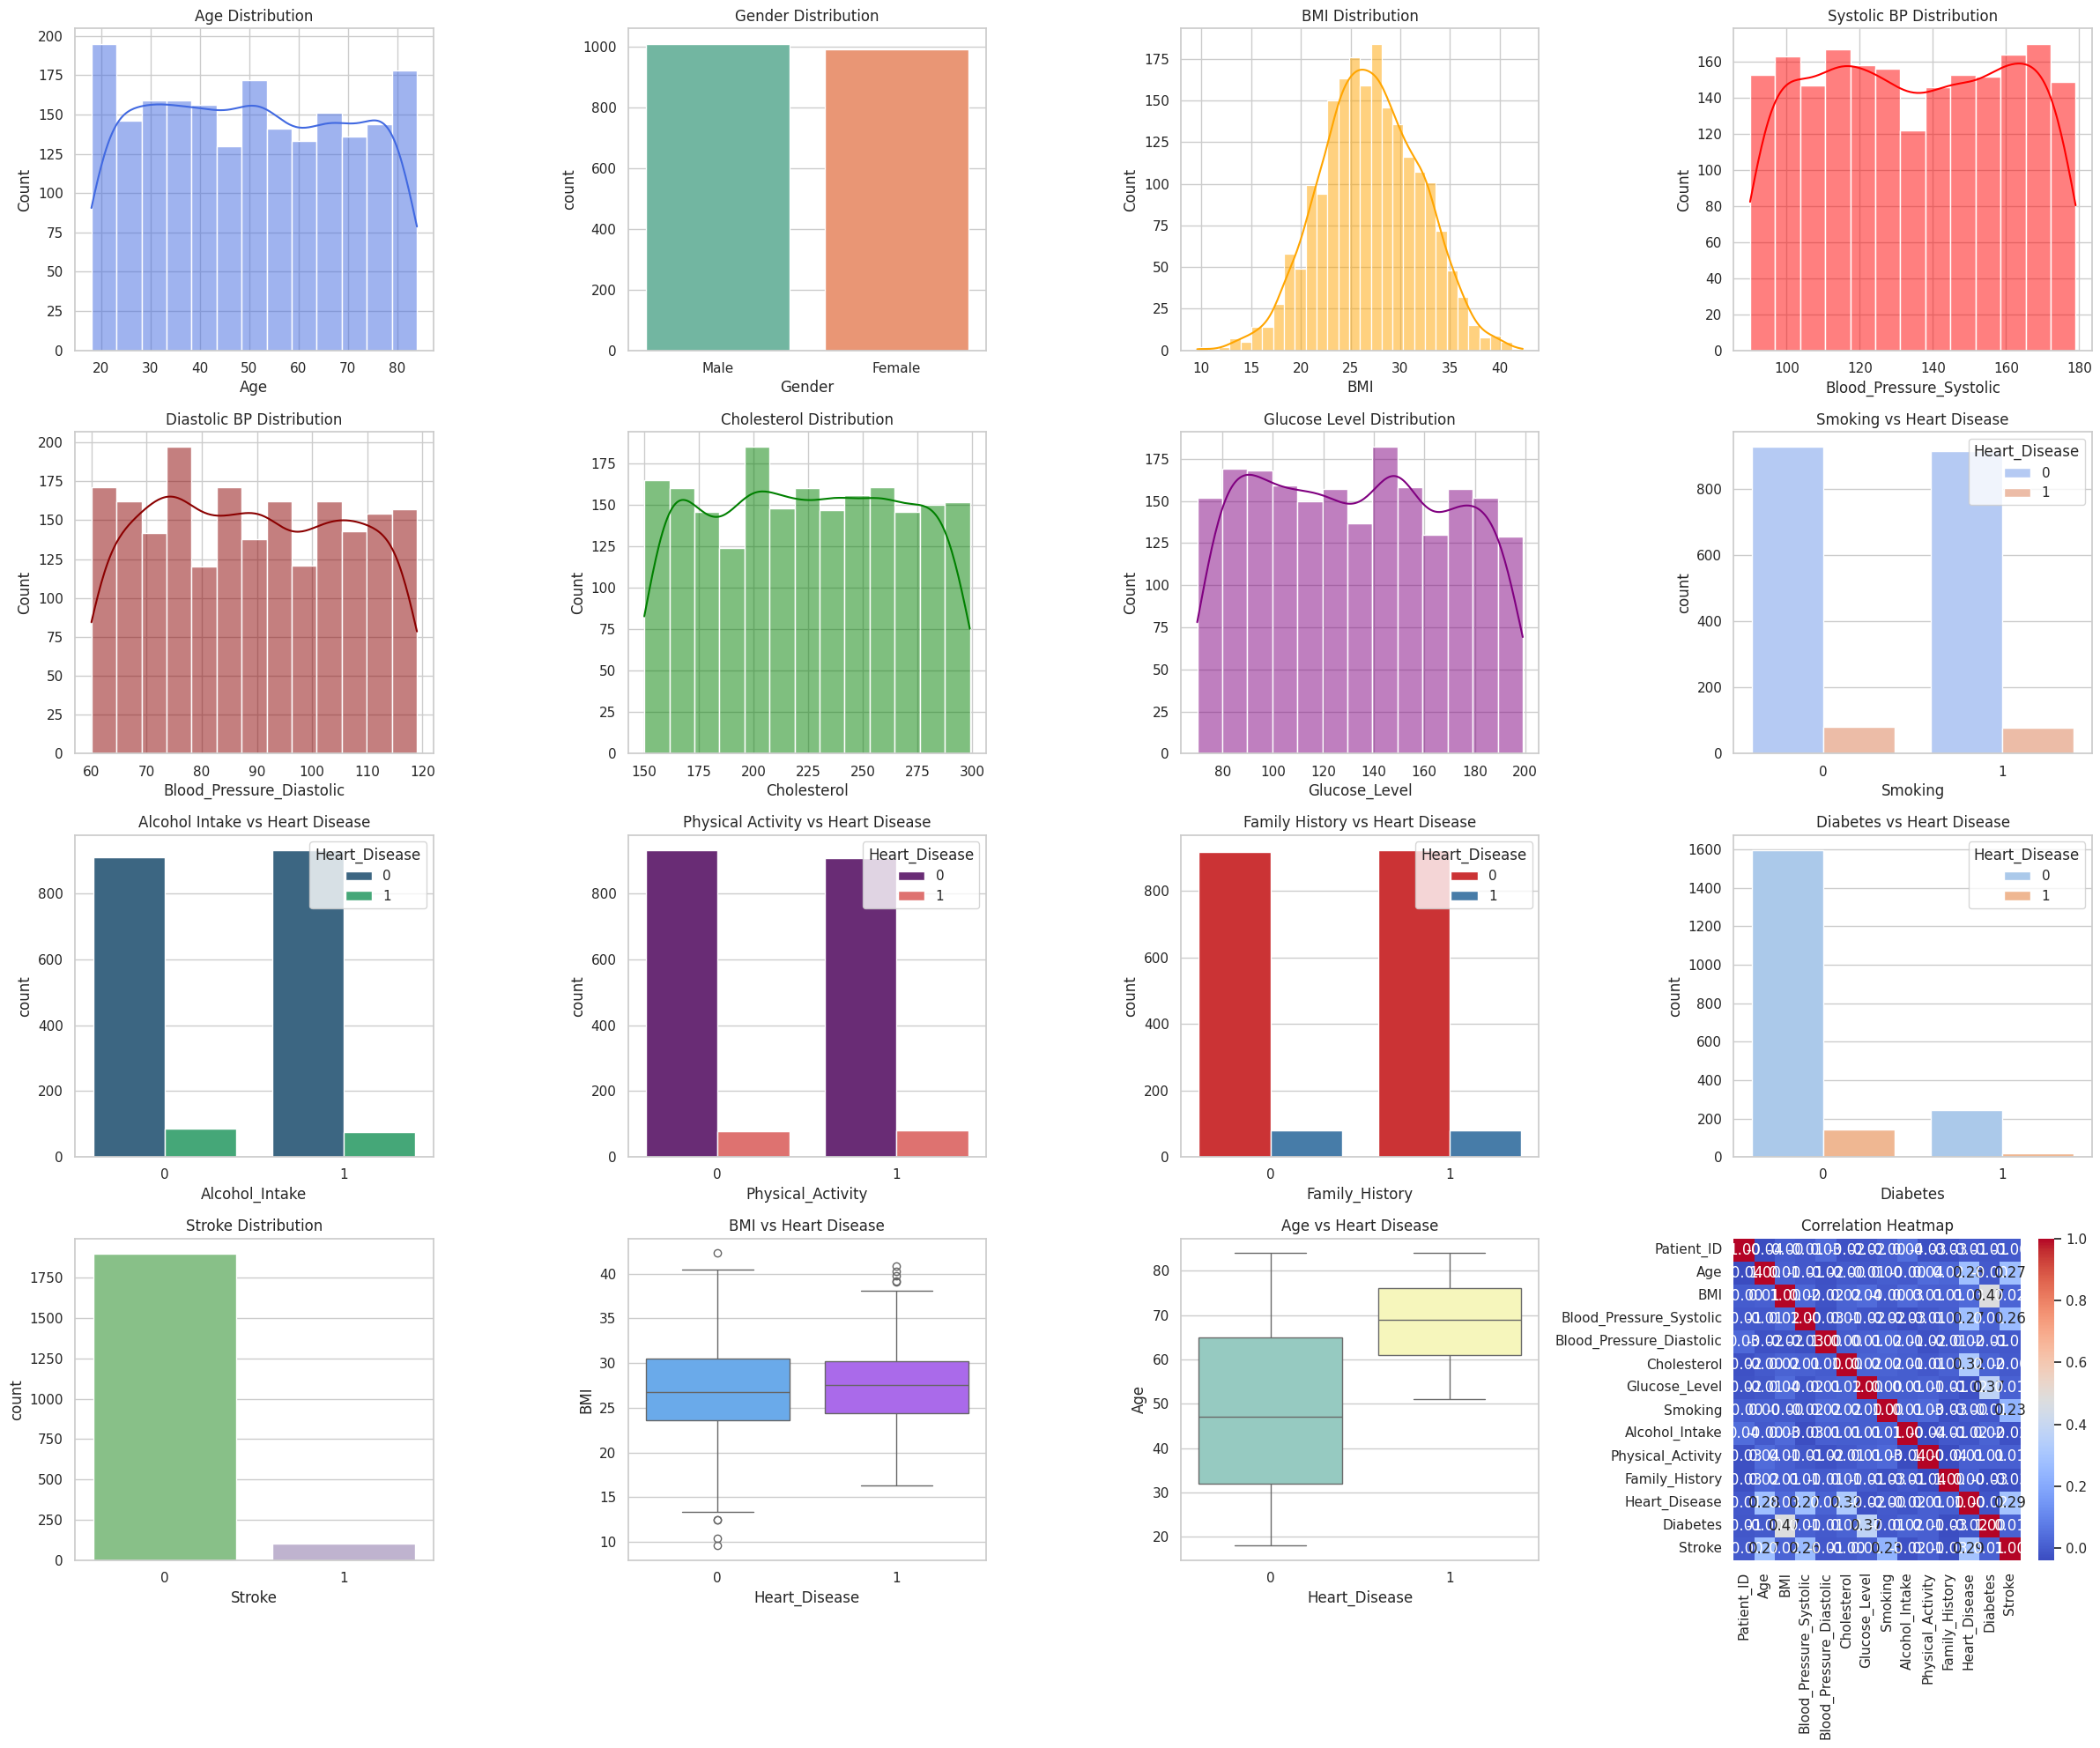

In [13]:
# Style settings
sns.set(style="whitegrid")
plt.figure(figsize=(24, 20))

# =======================
# 1. AGE DISTRIBUTION
# =======================
plt.subplot(4, 4, 1)
sns.histplot(df['Age'], kde=True, color='royalblue')
plt.title("Age Distribution")

# =======================
# 2. GENDER COUNT
# =======================
plt.subplot(4, 4, 2)
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title("Gender Distribution")

# =======================
# 3. BMI DISTRIBUTION
# =======================
plt.subplot(4, 4, 3)
sns.histplot(df['BMI'], kde=True, color='orange')
plt.title("BMI Distribution")

# =======================
# 4. BLOOD PRESSURE (SYS)
# =======================
plt.subplot(4, 4, 4)
sns.histplot(df['Blood_Pressure_Systolic'], kde=True, color='red')
plt.title("Systolic BP Distribution")

# =======================
# 5. BLOOD PRESSURE (DIA)
# =======================
plt.subplot(4, 4, 5)
sns.histplot(df['Blood_Pressure_Diastolic'], kde=True, color='darkred')
plt.title("Diastolic BP Distribution")

# =======================
# 6. CHOLESTEROL
# =======================
plt.subplot(4, 4, 6)
sns.histplot(df['Cholesterol'], kde=True, color='green')
plt.title("Cholesterol Distribution")

# =======================
# 7. GLUCOSE LEVEL
# =======================
plt.subplot(4, 4, 7)
sns.histplot(df['Glucose_Level'], kde=True, color='purple')
plt.title("Glucose Level Distribution")

# =======================
# 8. SMOKING VS HEART DISEASE
# =======================
plt.subplot(4, 4, 8)
sns.countplot(x='Smoking', hue='Heart_Disease', data=df, palette='coolwarm')
plt.title("Smoking vs Heart Disease")

# =======================
# 9. ALCOHOL INTAKE VS HEART DISEASE
# =======================
plt.subplot(4, 4, 9)
sns.countplot(x='Alcohol_Intake', hue='Heart_Disease', data=df, palette='viridis')
plt.title("Alcohol Intake vs Heart Disease")

# =======================
# 10. PHYSICAL ACTIVITY VS HEART DISEASE
# =======================
plt.subplot(4, 4, 10)
sns.countplot(x='Physical_Activity', hue='Heart_Disease', data=df, palette='magma')
plt.title("Physical Activity vs Heart Disease")

# =======================
# 11. FAMILY HISTORY VS HEART DISEASE
# =======================
plt.subplot(4, 4, 11)
sns.countplot(x='Family_History', hue='Heart_Disease', data=df, palette='Set1')
plt.title("Family History vs Heart Disease")

# =======================
# 12. DIABETES VS HEART DISEASE
# =======================
plt.subplot(4, 4, 12)
sns.countplot(x='Diabetes', hue='Heart_Disease', data=df, palette='pastel')
plt.title("Diabetes vs Heart Disease")

# =======================
# 13. STROKE COUNT
# =======================
plt.subplot(4, 4, 13)
sns.countplot(x='Stroke', data=df, palette='Accent')
plt.title("Stroke Distribution")

# =======================
# 14. BMI VS HEART DISEASE
# =======================
plt.subplot(4, 4, 14)
sns.boxplot(x='Heart_Disease', y='BMI', data=df, palette='cool')
plt.title("BMI vs Heart Disease")

# =======================
# 15. AGE VS HEART DISEASE
# =======================
plt.subplot(4, 4, 15)
sns.boxplot(x='Heart_Disease', y='Age', data=df, palette='Set3')
plt.title("Age vs Heart Disease")

# =======================
# 16. CORRELATION HEATMAP
# =======================
plt.subplot(4, 4, 16)
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")

# =======================
# FINAL LAYOUT
# =======================
plt.tight_layout()
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.9450
AUC Score: 0.9609

Random Forest
Accuracy: 0.9900
AUC Score: 0.9983

SVM
Accuracy: 0.9500
AUC Score: 0.9702


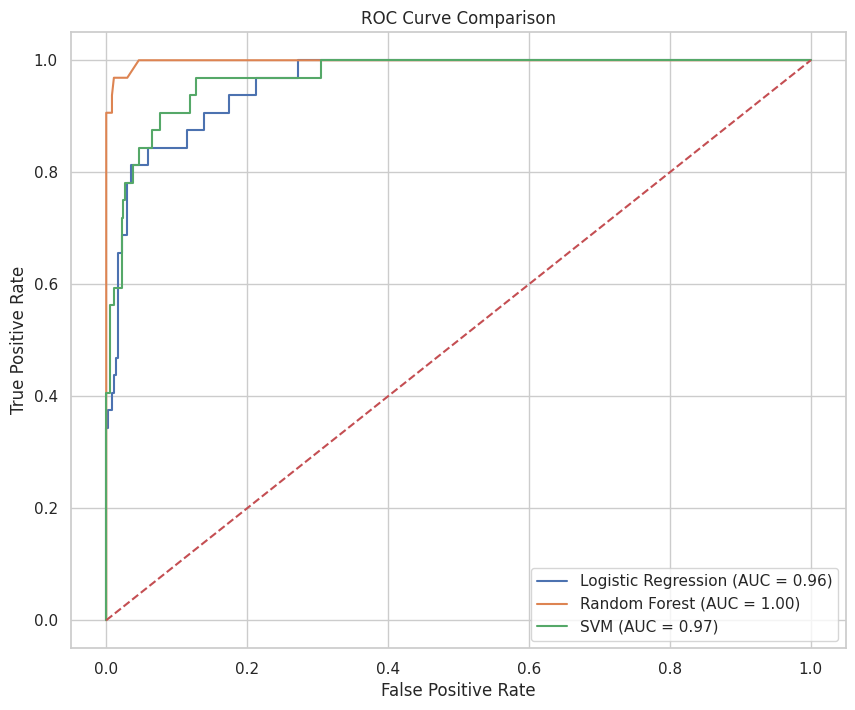


Final Model Comparison:
                     Accuracy       AUC
Logistic Regression     0.945  0.960938
Random Forest           0.990  0.998259
SVM                     0.950  0.970194


In [14]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve


# ==========================
# DEFINE FEATURES & TARGET
# ==========================
target = 'Heart_Disease'
X = df.drop(columns=[target, 'Patient_ID'])  # drop ID
y = df[target]

# ==========================
# IDENTIFY COLUMN TYPES
# ==========================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# ==========================
# LABEL ENCODING (NO LEAKAGE)
# ==========================
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# ==========================
# TRAIN-TEST SPLIT (BEFORE SCALING)
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================
# SCALING ONLY NUMERICAL DATA
# ==========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# ==========================
# MODELS
# ==========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

# ==========================
# TRAIN + EVALUATE
# ==========================
results = {}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Create pipeline (preprocessing + model)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {"Accuracy": acc, "AUC": auc}
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC Score: {auc:.4f}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# ==========================
# PLOT ROC CURVE
# ==========================
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================
# FINAL RESULTS TABLE
# ==========================
results_df = pd.DataFrame(results).T
print("\nFinal Model Comparison:")
print(results_df)

## Thank you..pls upvote!!!!!!!!!!!!!
